<a href="https://colab.research.google.com/github/Vicky231006/opencv_tomato_disease/blob/main/leaf_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Dataset Ingestion via kagglehub & Local Structure Extraction
import os
import shutil

# 1. Define final dataset path strings
TOMATO_FINAL_DIR = "./tomato_dataset"
VERIFIER_FINAL_DIR = "./verifier_dataset"

for path_dir in [TOMATO_FINAL_DIR, VERIFIER_FINAL_DIR]:
    if os.path.exists(path_dir):
        shutil.rmtree(path_dir)

# 2. Ingest PlantVillage dataset via kagglehub package dependency
print("Starting download of PlantVillage dataset via kagglehub...")
!pip install -q kagglehub
import kagglehub
raw_pv_path = kagglehub.dataset_download("arjuntejaswi/plant-village")
print("PlantVillage dataset downloaded successfully to:", raw_pv_path)

# 3. Ingest Background Noise Dataset using the local Kaggle archive download channel
print("Starting download of Background Noise Dataset...")
DOWNLOAD_DIR = "./raw_downloads"
if os.path.exists(DOWNLOAD_DIR):
    shutil.rmtree(DOWNLOAD_DIR)
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset -p {DOWNLOAD_DIR}

import zipfile
noise_zip = os.path.join(DOWNLOAD_DIR, "microsoft-catsvsdogs-dataset.zip")
noise_extract_path = os.path.join(DOWNLOAD_DIR, "noise_dataset")
with zipfile.ZipFile(noise_zip, 'r') as zip_ref:
    zip_ref.extractall(noise_extract_path)
print("Background noise archive extracted successfully.")

# 4. Filter, Sort, and Normalize Target Tomato Classes
print("Organizing target directory structures...")
tomato_src_classes = [
    'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight',
    'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]

# Locate source data node dynamically inside the kagglehub storage path
source_root_path = None
for root, dirs, files in os.walk(raw_pv_path):
    if any("Tomato" in d for d in dirs):
        source_root_path = root
        break

if not source_root_path:
    raise FileNotFoundError("Could not isolate source directories matching Tomato profiles in kagglehub path.")

os.makedirs(TOMATO_FINAL_DIR, exist_ok=True)
extracted_dirs = os.listdir(source_root_path)

for target_cls in tomato_src_classes:
    normalized_target = target_cls.replace("_", "").lower()
    match_found = False

    for ext_dir in extracted_dirs:
        if ext_dir.replace("_", "").lower() == normalized_target:
            src = os.path.join(source_root_path, ext_dir)
            dst = os.path.join(TOMATO_FINAL_DIR, target_cls)
            shutil.copytree(src, dst)
            print(f"Processed Class: {target_cls} ({len(os.listdir(dst))} images verified)")
            match_found = True
            break

    if not match_found:
        # Secondary logic check for truncated folder schemas like 'Tomato_Early_blight' mapped as 'Tomato___Early_blight'
        for ext_dir in extracted_dirs:
            if normalized_target in ext_dir.replace("_", "").lower() or ext_dir.replace("_", "").lower() in normalized_target:
                src = os.path.join(source_root_path, ext_dir)
                dst = os.path.join(TOMATO_FINAL_DIR, target_cls)
                shutil.copytree(src, dst)
                print(f"Processed Class via Substring Match: {target_cls} ({len(os.listdir(dst))} images verified)")
                match_found = True
                break

# 5. Seed Binary Leaf Verifier Datasets
print("Building Verification Image Sets...")
POS_VERIFY = os.path.join(VERIFIER_FINAL_DIR, "leaf")
NEG_VERIFY = os.path.join(VERIFIER_FINAL_DIR, "non_leaf")
os.makedirs(POS_VERIFY, exist_ok=True)
os.makedirs(NEG_VERIFY, exist_ok=True)

# Copy positive instances (leaves) from healthy tomato folders
healthy_src = os.path.join(TOMATO_FINAL_DIR, "Tomato_healthy")
if os.path.exists(healthy_src) and len(os.listdir(healthy_src)) > 0:
    for img_name in os.listdir(healthy_src)[:1200]:
        shutil.copy(os.path.join(healthy_src, img_name), os.path.join(POS_VERIFY, img_name))
else:
    # Fallback to alternative tomato variant if default target is unavailable
    alt_folder = os.listdir(TOMATO_FINAL_DIR)[0]
    alt_src = os.path.join(TOMATO_FINAL_DIR, alt_folder)
    for img_name in os.listdir(alt_src)[:1200]:
        shutil.copy(os.path.join(alt_src, img_name), os.path.join(POS_VERIFY, img_name))

# Copy negative instances (non-leaves) from downloaded noise dataset archive
cat_dog_root = os.path.join(noise_extract_path, "PetImages")
noise_count = 0
for root, dirs, files in os.walk(cat_dog_root):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')) and noise_count < 1200:
            src_file = os.path.join(root, f)
            if os.path.getsize(src_file) > 2048:
                shutil.copy(src_file, os.path.join(NEG_VERIFY, f"noise_{noise_count}.jpg"))
                noise_count += 1

print(f"Final Verification Count -> Class leaf: {len(os.listdir(POS_VERIFY))} images.")
print(f"Final Verification Count -> Class non_leaf: {len(os.listdir(NEG_VERIFY))} images.")

# 6. Purge working cache download paths
shutil.rmtree(DOWNLOAD_DIR)
print("Data trees successfully built and verified.")

Starting download of PlantVillage dataset via kagglehub...


100%|██████████| 329M/329M [00:01<00:00, 181MB/s]

Extracting files...


PlantVillage dataset downloaded successfully to: /root/.cache/kagglehub/datasets/arjuntejaswi/plant-village/versions/1
Starting download of Background Noise Dataset...
Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:06<00:00, 130MB/s]

Background noise archive extracted successfully.
Organizing target directory structures...
Processed Class: Tomato_Bacterial_spot (2127 images verified)
Processed Class: Tomato_Early_blight (1000 images verified)
Processed Class: Tomato_Late_blight (1909 images verified)
Processed Class: Tomato_Leaf_Mold (952 images verified)
Processed Class: Tomato_Septoria_leaf_spot (1771 images verified)
Processed Class: Tomato_Spider_mites_Two_spotted_spider_mite (1676 images verified)
Processed Class: Tomato__Target_Spot (1404 images verified)
Processed Class: Tomato__Tomato_YellowLeaf__Curl_Virus (3209 images verified)
Processed Class: Tomato__Tomato_mosaic_virus (373 images verified)
Proc

In [13]:
# Transforms & PyTorch Data Loading Components
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

# Geometric Transforms
standard_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 1. Binary Datasets
binary_full = datasets.ImageFolder(root=VERIFIER_FINAL_DIR, transform=standard_transforms)
b_train_sz = int(0.8 * len(binary_full))
b_train_set, b_val_set = random_split(binary_full, [b_train_sz, len(binary_full) - b_train_sz])
b_val_set.dataset.transform = val_transforms

# 2. Multi-Class Classifier Datasets
classifier_full = datasets.ImageFolder(root=TOMATO_FINAL_DIR, transform=standard_transforms)
c_train_sz = int(0.8 * len(classifier_full))
c_train_set, c_val_set = random_split(classifier_full, [c_train_sz, len(classifier_full) - c_train_sz])
c_val_set.dataset.transform = val_transforms

# Dataloaders Setup
BATCH_SIZE = 32
binary_loader = DataLoader(b_train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
binary_val_loader = DataLoader(b_val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classifier_loader = DataLoader(c_train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
classifier_val_loader = DataLoader(c_val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("PyTorch Data pipelines active.")

PyTorch Data pipelines active.


In [25]:
# Fine-Tuned Model Architecture and Texture-Focused Training Suite
import torch.nn as nn
import torch.optim as optim

def train_engine(model, train_loader, val_loader, criterion, optimizer, save_name, epochs=5):
    print(f"\nStarting Training Execution Loop for {save_name}...")
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

        # Validation Pass
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for v_imgs, v_labels in val_loader:
                v_imgs, v_labels = v_imgs.to(device), v_labels.to(device)
                v_outs = model(v_imgs)
                _, v_preds = v_outs.max(1)
                val_total += v_labels.size(0)
                val_correct += v_preds.eq(v_labels).sum().item()

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {running_loss/total:.4f} | Train Acc: {(correct/total)*100:.2f}% | Val Acc: {(val_correct/val_total)*100:.2f}%")

    torch.save(model.state_dict(), save_name)
    print(f"Saved configuration weights as {save_name}")

# 1. Train Binary Leaf Verifier
print("Initializing Leaf Verifier Architecture...")
verifier = models.mobilenet_v3_small(pretrained=True)
verifier.classifier[3] = nn.Linear(verifier.classifier[3].in_features, 2)
verifier = verifier.to(device)
train_engine(verifier, binary_loader, binary_val_loader, nn.CrossEntropyLoss(), optim.Adam(verifier.parameters(), lr=0.001), "leaf_verifier.pth", epochs=3)

# 2. Train Multi-Class Tomato Disease Classifier
print("\nInitializing Advanced Tomato Disease Classifier (ResNet50)...")
disease_model = models.resnet50(pretrained=True)
disease_model.fc = nn.Linear(disease_model.fc.in_features, len(tomato_src_classes))

# Unfreeze all convolutional blocks so the network can learn deep texture adjustments
for param in disease_model.parameters():
    param.requires_grad = True

# High LR on the new linear head, tiny LR on deep feature extraction blocks to protect base knowledge.
optimizer = optim.Adam([
    {'params': disease_model.fc.parameters(), 'lr': 0.001},
    {'params': disease_model.layer4.parameters(), 'lr': 0.0001},
    {'params': disease_model.layer3.parameters(), 'lr': 0.00001}
])

disease_model = disease_model.to(device)
train_engine(disease_model, classifier_loader, classifier_val_loader, nn.CrossEntropyLoss(), optimizer, "tomato_classifier.pth", epochs=5)

Initializing Leaf Verifier Architecture...

Starting Training Execution Loop for leaf_verifier.pth...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/3] | Train Loss: 0.0189 | Train Acc: 98.91% | Val Acc: 99.58%
Epoch [2/3] | Train Loss: 0.0060 | Train Acc: 99.95% | Val Acc: 99.79%
Epoch [3/3] | Train Loss: 0.0008 | Train Acc: 99.95% | Val Acc: 100.00%
Saved configuration weights as leaf_verifier.pth

Initializing Advanced Tomato Disease Classifier (ResNet50)...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Starting Training Execution Loop for tomato_classifier.pth...
Epoch [1/5] | Train Loss: 0.2572 | Train Acc: 91.74% | Val Acc: 98.41%
Epoch [2/5] | Train Loss: 0.0436 | Train Acc: 98.50% | Val Acc: 99.19%
Epoch [3/5] | Train Loss: 0.0396 | Train Acc: 98.64% | Val Acc: 97.50%
Epoch [4/5] | Train Loss: 0.0260 | Train Acc: 99.19% | Val Acc: 98.72%
Epoch [5/5] | Train Loss: 0.0363 | Train Acc: 98.83% | Val Acc: 97.85%
Saved configuration weights as tomato_classifier.pth


In [35]:
# Production Pipeline Core Execution Setup
import cv2
import numpy as np
from PIL import Image
from ultralytics import YOLO

class CropDiseasePipeline:
    def __init__(self, verifier_path="leaf_verifier.pth", classifier_path="tomato_classifier.pth"):
        self.tomato_classes = [
            'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight',
            'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite',
            'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus',
            'Tomato_healthy'
        ]

        # Load Leaf Verifier Weights
        self.leaf_verifier = models.mobilenet_v3_small(pretrained=False)
        self.leaf_verifier.classifier[3] = torch.nn.Linear(self.leaf_verifier.classifier[3].in_features, 2)
        if os.path.exists(verifier_path):
            self.leaf_verifier.load_state_dict(torch.load(verifier_path, map_location=device))
        self.leaf_verifier = self.leaf_verifier.eval().to(device)

        # Load Disease Classifier Weights
        self.classifier = models.resnet50(pretrained=False)
        self.classifier.fc = torch.nn.Linear(self.classifier.fc.in_features, len(self.tomato_classes))
        if os.path.exists(classifier_path):
            self.classifier.load_state_dict(torch.load(classifier_path, map_location=device))
        self.classifier = self.classifier.eval().to(device)

        # Load YOLOv8 Segmentor Instance
        self.severity_model = YOLO("yolov8n-seg.pt")

        # Hard Coded advices
        self.treatment_kb = {
            'Tomato_Bacterial_spot': {'Condition': 'Bacterial Spot', 'Remedy': 'Apply copper-based sprays combined with mancozeb.'},
            'Tomato_Early_blight': {'Condition': 'Early Blight', 'Remedy': 'Use chlorothalonil or copper fungicides. Trim lower branches.'},
            'Tomato_Late_blight': {'Condition': 'Late Blight', 'Remedy': 'Aggressive pathogen! Apply systemic mefenoxam fungicides immediately.'},
            'Tomato_Leaf_Mold': {'Condition': 'Leaf Mold', 'Remedy': 'Enhance airflow dynamics and lower ambient humidity levels.'},
            'Tomato_Septoria_leaf_spot': {'Condition': 'Septoria Leaf Spot', 'Remedy': 'Apply protective copper formulations and clear weeds.'},
            'Tomato_Spider_mites_Two_spotted_spider_mite': {'Condition': 'Two-Spotted Spider Mites', 'Remedy': 'Introduce predatory mites or spray horticultural oils.'},
            'Tomato__Target_Spot': {'Condition': 'Target Spot', 'Remedy': 'Apply azoxystrobin fungicides and optimize row separation spacing.'},
            'Tomato__Tomato_YellowLeaf__Curl_Virus': {'Condition': 'Yellow Leaf Curl Virus', 'Remedy': 'Deploy yellow sticky insect sheets to target Whiteflies.'},
            'Tomato__Tomato_mosaic_virus': {'Condition': 'Tomato Mosaic Virus', 'Remedy': 'No physical treatment. Remove immediately and sanitize tools.'},
            'Tomato_healthy': {'Condition': 'Healthy Foliage', 'Remedy': 'Maintain ongoing nutritional profiles and soil watering.'}
        }

    def assess_quality(self, img_path):
        img = cv2.imread(img_path)
        if img is None:
            return False, "Image unreadable.", {}
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur_val = cv2.Laplacian(gray, cv2.CV_64F).var()
        brightness = np.mean(gray)
        metrics = {"blur": round(blur_val, 2), "brightness": round(brightness, 2)}
        if blur_val < 70.0 or brightness < 30 or brightness > 230:
            return False, "Failed Quality Control Checks (Blur/Lighting issues).", metrics
        return True, "Passed QC", metrics

    def verify_is_leaf(self, img_pil):
        transform = transforms.Compose([
            transforms.Resize((224, 224)), transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        tensor = transform(img_pil).unsqueeze(0).to(device)
        with torch.no_grad():
            outputs = self.leaf_verifier(tensor)
            probs = torch.nn.functional.softmax(outputs, dim=1)
        # Binary target class index 0 represents the leaf subfolder
        return probs[0][0].item() >= 0.60

    def classify_crop_and_disease(self, img_pil):
        transform = transforms.Compose([
            transforms.Resize((224, 224)), transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        tensor = transform(img_pil).unsqueeze(0).to(device)
        with torch.no_grad():
            outputs = self.classifier(tensor)
            idx = torch.argmax(outputs, dim=1).item()
        detected = self.tomato_classes[idx]
        return "Tomato", (detected == 'Tomato_healthy'), detected

    def estimate_severity(self, img_path):
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        # 1. Broadened Leaf Mask: Captures deep greens, pale greens, and yellowing edges
        lower_green = np.array([25, 35, 30])
        upper_green = np.array([90, 255, 255])
        leaf_mask = cv2.inRange(hsv, lower_green, upper_green)

        # 2. Multi-Channel Pathology Ingestion
        # Channel A: Standard brown/yellow active disease spots
        lower_brown = np.array([8, 40, 30])
        upper_brown = np.array([30, 255, 220])
        mask_brown = cv2.inRange(hsv, lower_brown, upper_brown)

        # Channel B: Advanced charcoal/near-black dead tissue zones
        lower_dark_necrosis = np.array([0, 0, 5])
        upper_dark_necrosis = np.array([180, 255, 55])
        mask_dark = cv2.inRange(hsv, lower_dark_necrosis, upper_dark_necrosis)

        # Channel C: Late Blight Pale Yellow / Translucent Water-Soaked Halos
        lower_pale_halo = np.array([15, 30, 56])
        upper_pale_halo = np.array([34, 255, 255])
        mask_halo = cv2.inRange(hsv, lower_pale_halo, upper_pale_halo)

        # Combine all dynamic channels into a unified disease footprint matrix
        spot_mask = cv2.bitwise_or(mask_brown, mask_dark)
        spot_mask = cv2.bitwise_or(spot_mask, mask_halo)

        # 3. Morphological Operations to bridge scattered lesions together cleanly
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        spot_mask = cv2.morphologyEx(spot_mask, cv2.MORPH_CLOSE, kernel)
        spot_mask = cv2.morphologyEx(spot_mask, cv2.MORPH_OPEN, kernel)

        # 4. Isolate the final disease mask strictly to the leaf boundary context
        combined_leaf_structure = cv2.bitwise_or(leaf_mask, spot_mask)
        spot_mask = cv2.bitwise_and(spot_mask, combined_leaf_structure)

        # 5. Compute geometric surface area indices
        total_leaf_pixels = cv2.countNonZero(combined_leaf_structure)
        diseased_pixels = cv2.countNonZero(spot_mask)

        if total_leaf_pixels > 0:
            pct = (diseased_pixels / total_leaf_pixels) * 100
        else:
            pct = 0.0

        # 6. Generate the visual overlay matrix so unpacking succeeds
        annotated_view = img_rgb.copy()
        contours, _ = cv2.findContours(spot_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(annotated_view, contours, -1, (255, 0, 0), 2)

        cv2.putText(annotated_view, f"Necrosis: {round(pct, 1)}%", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

        # ⚡ FIXED: Returns BOTH expected parameters to stop the unpacking error
        return round(pct, 2), annotated_view

    def run_pipeline(self, img_path):
        passed, msg, q_metrics = self.assess_quality(img_path)
        if not passed:
            return {"status": "Rejected", "reason": msg}

        img_pil = Image.open(img_path).convert("RGB")
        if not self.verify_is_leaf(img_pil):
            return {"status": "Rejected", "reason": "Object validation failed. Target is not a crop leaf structure."}

        crop, is_healthy, final_class = self.classify_crop_and_disease(img_pil)
        pct, annotated_view = self.estimate_severity(img_path)

        return {
            "status": "Processed", "crop": crop, "is_healthy": is_healthy,
            "disease": final_class, "severity": pct if not is_healthy else 0.0,
            "visual": annotated_view, "treatment": self.treatment_kb[final_class]
        }


FINAL SYSTEM PIPELINE REPORT
Target Species:       Tomato
Health Condition:     PATHOGEN DETECTED
Diagnosed Category:   Tomato_Leaf_Mold
Severity Surface Area: 17.21%
Action Remedy:        Enhance airflow dynamics and lower ambient humidity levels.


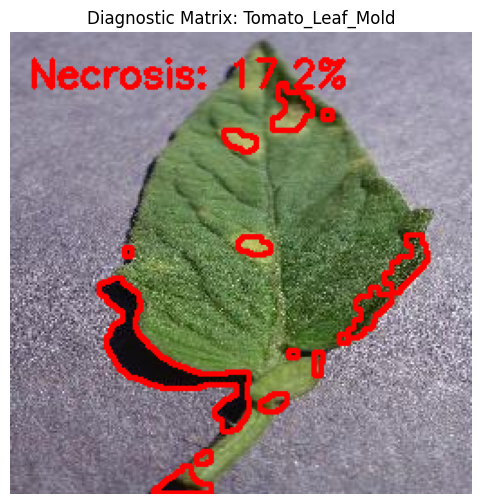

In [44]:
# End-to-End Test Execution and Visual Verification Matrix
import matplotlib.pyplot as plt

# Pull an image file from the local dataset tree to validate the complete pipeline flow
target_test_dir = "./tomato_dataset/Tomato_Leaf_Mold"
if os.path.exists(target_test_dir) and len(os.listdir(target_test_dir)) > 0:
    sample_file = os.path.join(target_test_dir, os.listdir(target_test_dir)[0])

    # Run Inference Pipeline Engine Instance
    engine = CropDiseasePipeline()
    report = engine.run_pipeline(sample_file)

    print("\nFINAL SYSTEM PIPELINE REPORT")
    if report["status"] == "Processed":
        print(f"Target Species:       {report['crop']}")
        print(f"Health Condition:     {'HEALTHY' if report['is_healthy'] else 'PATHOGEN DETECTED'}")
        print(f"Diagnosed Category:   {report['disease']}")
        print(f"Severity Surface Area: {report['severity']}%")
        print(f"Action Remedy:        {report['treatment']['Remedy']}")

        plt.figure(figsize=(6, 6))
        plt.imshow(report["visual"])
        plt.title(f"Diagnostic Matrix: {report['disease']}")
        plt.axis("off")
        plt.show()
    else:
        print(f"Pipeline Rejection Triggered: {report['reason']}")
else:
    print("Test folder directory mapping empty or missing. Check download extraction status.")